# Chapter 11: Novelty and Outlier Detection

## 📋 Summary

Outlier and novelty detection identifies data points that deviate significantly from the norm. This is critical for fraud detection, network intrusion detection, manufacturing quality control, and medical diagnostics. This chapter covers four main techniques: Isolation Forest, One-Class SVM, Local Outlier Factor (LOF), and Elliptic Envelope, along with evaluation methods and strategies for handling detected outliers.

---

## 🧠 Theoretical Explanation

### Outlier vs Novelty Detection
- **Outlier detection**: Trained on data that may already contain outliers. Unsupervised.
- **Novelty detection**: Trained on clean data; detects new, previously unseen anomalies.

### Isolation Forest
Isolates anomalies by randomly selecting features and split values. **Anomalies are easier to isolate** — they require fewer splits to separate from the rest. 

- Builds many random trees; anomaly score = average path length to isolate a point
- Short path → anomalous; Long path → normal
- Very fast: O(n log n), works well with high-dimensional data

### One-Class SVM
Learns a boundary around the "normal" training data by mapping data to a high-dimensional space and finding a maximal-margin hyperplane that separates normal points from the origin. Good for novelty detection on non-Gaussian distributions.

### Local Outlier Factor (LOF)
Measures the **local density deviation** of a point compared to its neighbors:
- If a point's neighborhood is much less dense than its neighbors' neighborhoods → it's an outlier
- LOF score ≈ 1: normal; LOF score >> 1: outlier
- Good for datasets where clusters have different densities

### Elliptic Envelope
Assumes data is Gaussian. Fits a robust covariance estimator and identifies outliers as points beyond a Mahalanobis distance threshold. Best for unimodal Gaussian-like data.

### Handling Detected Outliers
Once outliers are detected:
1. **Remove** them (if they represent data errors)
2. **Cap/winsorize** them (replace with threshold values)
3. **Investigate** them (they might be the most valuable data points!)
4. **Train two models** — one with, one without outliers — and compare


## 11.1 Isolation Forest

              precision    recall  f1-score   support

          -1       0.91      1.00      0.95        30
           1       1.00      0.99      0.99       300

    accuracy                           0.99       330
   macro avg       0.95      0.99      0.97       330
weighted avg       0.99      0.99      0.99       330



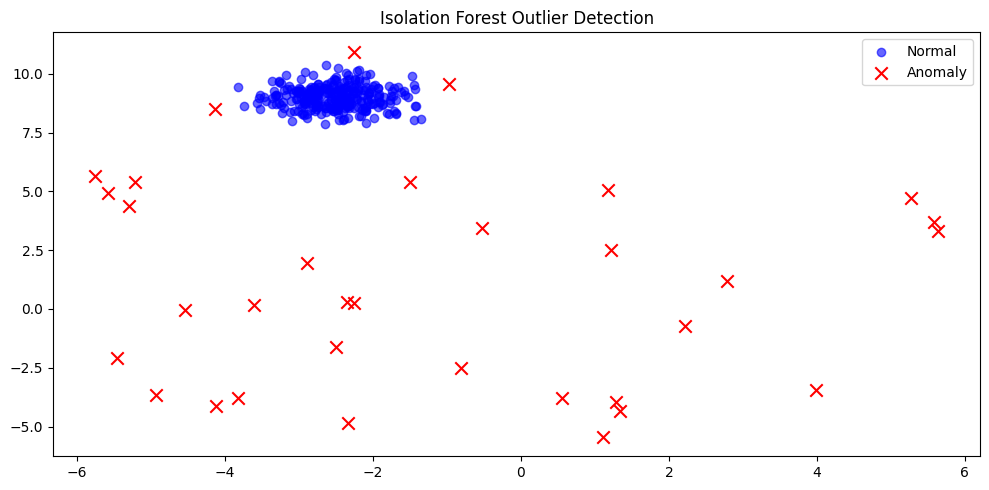

In [1]:
from sklearn.ensemble import IsolationForest
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt

# Create data with outliers
np.random.seed(42)
X_normal, _ = make_blobs(n_samples=300, centers=1, cluster_std=0.5, random_state=42)
X_outliers = np.random.uniform(low=-6, high=6, size=(30, 2))
X = np.vstack([X_normal, X_outliers])
y_true = np.array([1]*300 + [-1]*30)  # 1=normal, -1=outlier

iso_forest = IsolationForest(n_estimators=100, contamination=0.1, random_state=42)
y_pred = iso_forest.fit_predict(X)

from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred))

plt.figure(figsize=(10, 5))
plt.scatter(X[y_pred==1, 0], X[y_pred==1, 1], c='blue', label='Normal', alpha=0.6)
plt.scatter(X[y_pred==-1, 0], X[y_pred==-1, 1], c='red', s=80, label='Anomaly', marker='x')
plt.title('Isolation Forest Outlier Detection')
plt.legend(); plt.tight_layout(); plt.show()

## 11.2 Local Outlier Factor (LOF)

In [2]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
y_pred_lof = lof.fit_predict(X)

print('LOF Results:')
print(classification_report(y_true, y_pred_lof))

# LOF scores (negative = more outlier-like)
lof_scores = -lof.negative_outlier_factor_
print(f'Mean LOF score for normal: {lof_scores[y_true==1].mean():.3f}')
print(f'Mean LOF score for outliers: {lof_scores[y_true==-1].mean():.3f}')

LOF Results:
              precision    recall  f1-score   support

          -1       0.36      0.40      0.38        30
           1       0.94      0.93      0.93       300

    accuracy                           0.88       330
   macro avg       0.65      0.67      0.66       330
weighted avg       0.89      0.88      0.88       330

Mean LOF score for normal: 1.117
Mean LOF score for outliers: 3.093


## 11.3 One-Class SVM for Novelty Detection

In [3]:
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler

# One-Class SVM is for novelty detection — train ONLY on normal data
X_train_normal = X_normal  # Only normal data

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_normal)
X_test_scaled = scaler.transform(X)

oc_svm = OneClassSVM(kernel='rbf', nu=0.1, gamma='scale')
oc_svm.fit(X_train_scaled)
y_pred_svm = oc_svm.predict(X_test_scaled)

print('One-Class SVM Results:')
print(classification_report(y_true, y_pred_svm))

One-Class SVM Results:
              precision    recall  f1-score   support

          -1       0.49      1.00      0.66        30
           1       1.00      0.90      0.95       300

    accuracy                           0.91       330
   macro avg       0.75      0.95      0.80       330
weighted avg       0.95      0.91      0.92       330



## 11.4 Elliptic Envelope

In [4]:
from sklearn.covariance import EllipticEnvelope

ee = EllipticEnvelope(contamination=0.1, random_state=42)
y_pred_ee = ee.fit_predict(X)

print('Elliptic Envelope Results:')
print(classification_report(y_true, y_pred_ee))

Elliptic Envelope Results:
              precision    recall  f1-score   support

          -1       0.91      1.00      0.95        30
           1       1.00      0.99      0.99       300

    accuracy                           0.99       330
   macro avg       0.95      0.99      0.97       330
weighted avg       0.99      0.99      0.99       330



## 11.5 Comparing All Methods

In [5]:
from sklearn.metrics import f1_score
import pandas as pd

results = [
    ('Isolation Forest', y_pred),
    ('LOF', y_pred_lof),
    ('One-Class SVM', y_pred_svm),
    ('Elliptic Envelope', y_pred_ee)
]

rows = []
for name, pred in results:
    f1 = f1_score(y_true, pred, pos_label=-1)
    rows.append({'Method': name, 'F1 (outlier class)': round(f1, 4)})

pd.DataFrame(rows)

,Method,F1 (outlier class)
0,Isolation Forest,0.9524
1,LOF,0.3810
2,One-Class SVM,0.6593
3,Elliptic Envelope,0.9524


## 🔑 Key Takeaways

- **Isolation Forest** is the most scalable and generally effective — great first choice.
- **LOF** detects local anomalies in datasets with varying densities.
- **One-Class SVM** is best for novelty detection when you have clean training data.
- **Elliptic Envelope** is ideal when your data is approximately Gaussian.
- The `contamination` parameter controls the expected proportion of outliers — set it based on domain knowledge.
- Outliers can be valuable — always investigate before simply removing them.
